In [1]:
import pandas as pd

df = pd.read_parquet(
    "../data/processed/reviews_clean.parquet"
)

df.head()

,review_id,user_id,product_id,review_text,rating,timestamp,label
0,Z_wgGcI8_Txo87Wz7CxdrQ,cM9GIlk61Qh2thLyJyxNyA,N7juvW8YoFIj7sEBzVF8GQ,as new resident chicago los angeles i mission ...,5,2010-09-17,1
1,NJfQb03MSstqYagt860Oaw,SVlSPBnjCzY2Bu9n8y2C5A,o54U2VkQama8FI30qDkWvw,great place rarely wait fairly easy find parki...,5,2008-01-31,0
2,2uao3bK9iSV4fuMwuSYCiQ,5HYWhPS3ozYifieW0lWMUw,1QKqtC4vML3QhkrSzwR_tQ,back bar makes feel though transported china s...,5,2010-03-31,1
3,6mVU2JfeSbQ-5RnPm-K6eA,dgKmhiTypR34XNPrMtQyMA,4wreIFjaPMppyEnzKHbozg,hands one favorite tourist restaurants city th...,5,2010-04-26,0
4,e25NUAMnVf7-t8-vBO_drA,uB3n74XHDFUKwHxfK5lDvA,N7juvW8YoFIj7sEBzVF8GQ,service impeccable staff helpful owner works h...,5,2010-09-07,1


In [2]:
df.shape

(12409, 7)

In [3]:
df.columns

Index(['review_id', 'user_id', 'product_id', 'review_text', 'rating',
       'timestamp', 'label'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12409 entries, 0 to 12408
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   review_id    12409 non-null  str           
 1   user_id      12409 non-null  str           
 2   product_id   12409 non-null  str           
 3   review_text  12409 non-null  str           
 4   rating       12409 non-null  int64         
 5   timestamp    12409 non-null  datetime64[us]
 6   label        12409 non-null  int64         
dtypes: datetime64[us](1), int64(2), str(4)
memory usage: 6.8 MB


In [5]:
df.isnull().sum()

review_id      0
user_id        0
product_id     0
review_text    0
rating         0
timestamp      0
label          0
dtype: int64

In [6]:
df["label"].value_counts()

label
0    6205
1    6204
Name: count, dtype: int64

In [7]:
# Review length analysis

df["review_length"] = (
    df["review_text"]
    .str.len()
)

df["review_length"].describe()

count    12409.000000
mean       453.725602
std        424.136235
min          1.000000
25%        176.000000
50%        330.000000
75%        590.000000
max       3676.000000
Name: review_length, dtype: float64

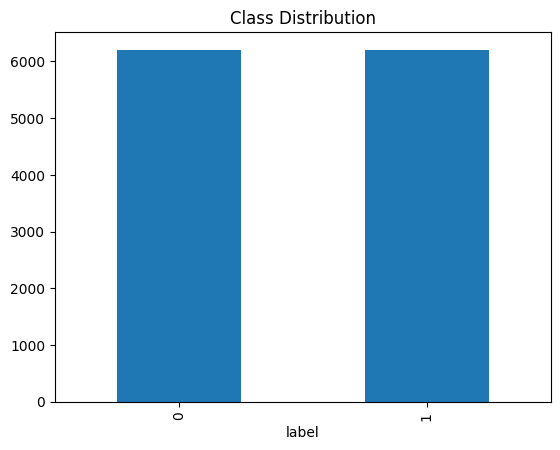

In [8]:
# Class Imbalance Visualization

import matplotlib.pyplot as plt

df["label"].value_counts().plot(
    kind="bar"
)

plt.title("Class Distribution")

plt.show()

<Axes: xlabel='timestamp'>

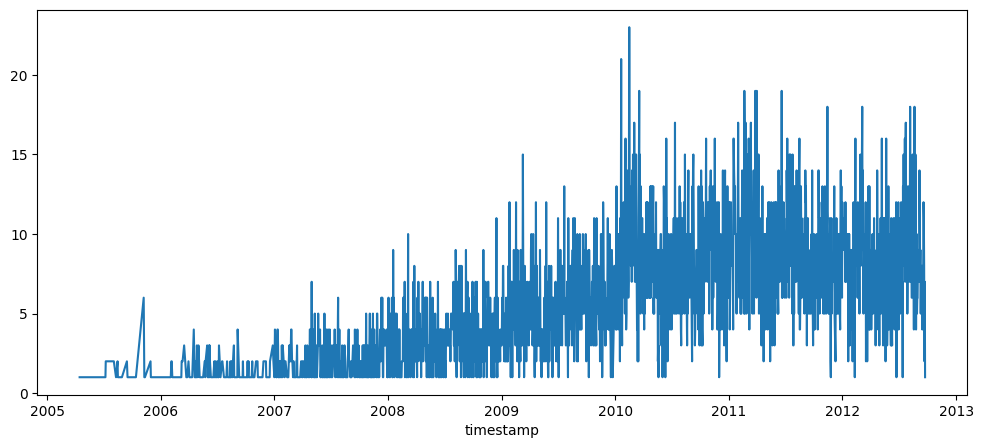

In [9]:
# Temporal Analysis

df["timestamp"] = pd.to_datetime(
    df["timestamp"]
)

reviews_per_day = (
    df.groupby(
        df["timestamp"].dt.date
    ).size()
)

reviews_per_day.plot(figsize=(12,5))